<div style="text-align: center; padding: 30px 10px;">

<h2 style="font-size: 30px; margin-top: 5px;">
Лабораторная работа 5. Парсинг.
</h2>

<hr style="width: 60%; border: 1px solid #10069f; margin: 25px auto;">

</div>


Если Вы видите <b><font color="#FF69B4"> Ваш ответ здесь </font></b> - надо поменять текст внутри блока на свой текстовый ответ на вопрос.


ВАЖНО! Здесь и далее от вас ожидается чистый код, близкий к тому, что нужно в индустрии. В контексте данной лабораторной работы ожидаются корректные названия у полей, методов и переменных, которые вы вводите; корректная инкапсуляция - нижнее подчеркивание или два перед названием метода или атрибута. Для корректной инкапсуляции можно (и даже нужно) добавлять нижние подчеркивания даже к названиям методов/атрибутов из условий задач :)





Выбери свой вариант из таблички курса и работай дальше с ним.



Вариант A. Производство картофеля по странам мира (тысяч тонн)

https://ru.wikipedia.org/wiki/%D0%9A%D0%B0%D1%80%D1%82%D0%BE%D1%84%D0%B5%D0%BB%D0%B5%D0%B2%D0%BE%D0%B4%D1%81%D1%82%D0%B2%D0%BE


Вариант B. Производство сахарной свёклы по миру.

https://ru.wikipedia.org/wiki/%D0%A1%D0%B0%D1%85%D0%B0%D1%80%D0%BD%D0%B0%D1%8F_%D1%81%D0%B2%D1%91%D0%BA%D0%BB%D0%B0

(Как географические координаты можно брать столицы стран).

**Вариант C. Производство зелёного гороха по странам и годам.**
https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D1%85


Вариант D. Крупнейшие производители сои (тысяч тонн).

https://ru.wikipedia.org/wiki/%D0%A1%D0%BE%D1%8F

Вариант E. Ведущие производители кукурузы (тысяч тонн)

https://ru.wikipedia.org/wiki/%D0%9A%D1%83%D0%BA%D1%83%D1%80%D1%83%D0%B7%D0%B0

Вариант F. Список стран по производству риса

https://ru.wikipedia.org/wiki/%D0%A1%D0%BF%D0%B8%D1%81%D0%BE%D0%BA_%D1%81%D1%82%D1%80%D0%B0%D0%BD_%D0%BF%D0%BE_%D0%BF%D1%80%D0%BE%D0%B8%D0%B7%D0%B2%D0%BE%D0%B4%D1%81%D1%82%D0%B2%D1%83_%D1%80%D0%B8%D1%81%D0%B0

Вариант G. Крупнейшие производители томатов в тысячах тонн

https://ru.wikipedia.org/wiki/%D0%A2%D0%BE%D0%BC%D0%B0%D1%82

## Часть 1. Скачай данные из табличек + информацию о географических данных (широта и долгота) центра данного региона / столицы + подчисти датасет. 2 балла.

In [3]:

import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time
from datetime import datetime, timedelta
import re

In [5]:
class DataParser:

    def __init__(self, url: str):
        self._url = url
        self._raw_data = None
        self._cleaned_data = None
        self._geo_data = None
        self._headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        }

    def _fetch_data(self):
        response = requests.get(self._url, headers=self._headers)
        response.raise_for_status()
        soup = BeautifulSoup(response.content, 'html.parser')

        tables = soup.find_all('table', {'class': 'wikitable'})
        if not tables:
            tables = soup.find_all('table', class_='wikitable')
        for table in tables:
            if 'страна' in table.get_text().lower() or 'country' in table.get_text().lower():
                self._raw_data = pd.read_html(str(table))[0]
                break
        if self._raw_data is None:
            self._raw_data = pd.read_html(str(tables[0]))[0]

        return self._raw_data

    def _clean_data(self):
        df = self._raw_data.copy()
        new_columns = []
        for col in df.columns:
            col_str = str(col).lower()
            if 'страна' in col_str or 'country' in col_str:
                new_columns.append('country')
            elif '202' in col_str:
                new_columns.append('2023')
            else:
                new_columns.append(f'col_{len(new_columns)}')

        if len(new_columns) == len(df.columns):
            df.columns = new_columns

        if 'country' in df.columns:
            df['country'] = df['country'].apply(
                lambda x: re.sub(r'\[.*?\]', '', str(x)).strip()
            )
        numeric_cols = [col for col in df.columns if col not in ['country']]
        for col in numeric_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        df = df.dropna(subset=['country'])
        df = df.reset_index(drop=True)

        self._cleaned_data = df
        return self._cleaned_data

    def _get_coordinates(self, country_name: str, max_retries: int = 3):
        geolocator = Nominatim(user_agent="geo_mapper_app")
        geocode = RateLimiter(geolocator.geocode, max_retries=max_retries, delay=1)

        try:
            location = geocode(f"{country_name} capital")
            if location:
                return (location.latitude, location.longitude)

            location = geocode(country_name)
            if location:
                return (location.latitude, location.longitude)
        except Exception as e:
            print(f"Ошибка получения координат для {country_name}: {e}")

        return (None, None)

    def add_geodata(self, limit: int = 25) -> pd.DataFrame:
        if self._cleaned_data is None:
            self._clean_data()
        df = self._cleaned_data.copy()
        df['latitude'] = None
        df['longitude'] = None

        last_year_col = [col for col in df.columns if col.isdigit()][-1]
        df_sorted = df.sort_values(last_year_col, ascending=False).head(limit)
        for idx, row in df_sorted.iterrows():
            lat, lon = self._get_coordinates(row['country'])
            df_sorted.loc[idx, 'latitude'] = lat
            df_sorted.loc[idx, 'longitude'] = lon
            time.sleep(0.5)

        self._geo_data = df_sorted
        return self._geo_data

    def get_data(self):
        if self._cleaned_data is None:
            self._fetch_data()
            self._clean_data()
        return self._cleaned_data

    def get_geo_data(self):
        if self._geo_data is None:
            self.add_geodata()
        return self._geo_data


In [6]:

class WikipediaProductionParser:

    def __init__(self, url: str):
        self._url = url
        self._data = None
        self._headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        }

    def _find_production_table(self, soup: BeautifulSoup):
        tables = soup.find_all('table', class_=re.compile('wikitable'))

        for table in tables:
            table_text = table.get_text().lower()

            production_keywords = ['производств', 'production', 'тыс', 'тонн',
                                   'million', 'tonnes', 'pea', 'горох']

            if any(keyword in table_text for keyword in production_keywords):
                try:
                    df = pd.read_html(str(table))[0]
                    if len(df.columns) >= 2 and df.shape[0] > 5:
                        return df
                except:
                    continue

        return None

    def fetch_data(self):
        print(f"Парсинг страницы: {self._url}")

        response = requests.get(self._url, headers=self._headers)
        response.raise_for_status()
        soup = BeautifulSoup(response.content, 'html.parser')
        df = self._find_production_table(soup)

        if df is None:
            all_tables = soup.find_all('table')
            print(f"\nНайдено таблиц на странице: {len(all_tables)}")
            print("Классы таблиц:")
            for i, table in enumerate(all_tables):
                classes = table.get('class', ['no-class'])
                print(f"  Таблица {i+1}: {classes}")
            raise ValueError("Не удалось найти таблицу с данными о производстве")

        self._data = df
        return self._data

    def clean_data(self, df: pd.DataFrame):
        print(f"\nИсходные столбцы: {list(df.columns)}")
        new_columns = []
        for col in df.columns:
            col_str = str(col).strip().lower()

            year_match = re.search(r'20\d{2}', col_str)
            if year_match:
                new_columns.append(year_match.group())
            elif 'страна' in col_str or 'country' in col_str:
                new_columns.append('country')
            else:
                new_columns.append(col_str)

        if len(new_columns) == len(df.columns):
            df.columns = new_columns

        if 'country' in df.columns:
            df['country'] = df['country'].apply(
                lambda x: re.sub(r'\[.*?\]', '', str(x)).strip()
            )
        else:
            first_col = df.columns[0]
            df = df.rename(columns={first_col: 'country'})
            df['country'] = df['country'].apply(
                lambda x: re.sub(r'\[.*?\]', '', str(x)).strip()
            )
        for col in df.columns:
            if col != 'country':
                df[col] = pd.to_numeric(df[col], errors='coerce')
        df = df.dropna(subset=['country'])
        df = df[df['country'] != '']

        return df.reset_index(drop=True)

urls_to_try = [
    "https://en.wikipedia.org/wiki/List_of_countries_by_pea_production",
    "https://en.wikipedia.org/wiki/Pea",
]

data = None
parser = None

for url in urls_to_try:
    try:
        parser = WikipediaProductionParser(url)
        data = parser.fetch_data()
        print(f"\nУспешно получены данные с: {url}")
        break
    except Exception as e:
        print(f"Не удалось спарсить {url}: {e}")
        continue

if data is None:
    print("Таблица с производством гороха не найдена на указанных URL")

    print("\nПроверка страницы https://ru.wikipedia.org/wiki/Горох:")
    response = requests.get("https://ru.wikipedia.org/wiki/Горох",
                           headers={'User-Agent': 'Mozilla/5.0'})
    soup = BeautifulSoup(response.content, 'html.parser')

    all_tables = soup.find_all('table')
    print(f"Всего таблиц на странице: {len(all_tables)}")
    for i, table in enumerate(all_tables):
        classes = table.get('class', ['без класса'])
        print(f"Таблица {i+1}: классы={classes}")
        text_preview = table.get_text()[:100].replace('\n', ' ').strip()
        if text_preview:
            print(f"Содержание: {text_preview}...")
    print("На странице о горохе нет статистической таблицы производства")


Парсинг страницы: https://en.wikipedia.org/wiki/List_of_countries_by_pea_production
Не удалось спарсить https://en.wikipedia.org/wiki/List_of_countries_by_pea_production: 404 Client Error: Not Found for url: https://en.wikipedia.org/wiki/List_of_countries_by_pea_production
Парсинг страницы: https://en.wikipedia.org/wiki/Pea

Успешно получены данные с: https://en.wikipedia.org/wiki/Pea


/tmp/ipykernel_1002/2177014147.py:21: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]


In [7]:

import time
from geopy.geocoders import Nominatim

print("Обработка данных из парсинга")

class PeaProductionCleaner:

    def __init__(self, raw_df):
        self._raw_df = raw_df
        self._cleaned_df = None
        self._geo_df = None

    def clean(self) -> pd.DataFrame:
        df = self._raw_df.copy()
        df.columns = ['country', 'production_tonnes']
        df = df[~df['country'].astype(str).str.contains('Source|FAOSTAT', case=False, na=False)]
        df = df[~df['production_tonnes'].astype(str).str.contains('Source|FAOSTAT', case=False, na=False)]
        df = df[~df['country'].astype(str).str.contains('World', case=False, na=False)]

        def clean_number(x):
            if pd.isna(x):
                return None
            x_str = str(x).strip()
            x_str = re.sub(r'[,\s]', '', x_str)
            if x_str.isdigit():
                return float(x_str)
            return None

        df['production_tonnes'] = df['production_tonnes'].apply(clean_number)
        df = df.dropna(subset=['production_tonnes'])
        df = df.reset_index(drop=True)
        df['production_thousands'] = (df['production_tonnes'] / 1000).round(1)

        self._cleaned_df = df
        return self._cleaned_df

    def get_coordinates_simple(self, country_name: str):
        known_coords = {
            'China': (35.8617, 104.1954),
            'India': (20.5937, 78.9629),
            'Pakistan': (30.3753, 69.3451),
            'France': (46.6034, 1.8883),
            'United States': (37.0902, -95.7129),
            'Algeria': (28.0339, 1.6596),
            'United Kingdom': (55.3781, -3.4360),
        }

        if country_name in known_coords:
            return known_coords[country_name]

        try:
            geolocator = Nominatim(user_agent="pea_analyzer", timeout=10)
            location = geolocator.geocode(country_name, exactly_one=True)
            if location:
                return (location.latitude, location.longitude)
        except:
            pass

        return (None, None)

    def add_geo_data(self) -> pd.DataFrame:
        if self._cleaned_df is None:
            self.clean()

        df = self._cleaned_df.copy()

        print("\nПолучение координат для стран")
        df['latitude'] = None
        df['longitude'] = None

        for idx, row in df.iterrows():
            country = row['country']
            print(f"{country}", end=" ")
            lat, lon = self.get_coordinates_simple(country)
            df.loc[idx, 'latitude'] = lat
            df.loc[idx, 'longitude'] = lon
            print(f"({lat:.2f}, {lon:.2f})" if lat else "не найдено")
            time.sleep(0.5)

        self._geo_df = df
        return self._geo_df

    def get_cleaned_data(self):
        return self._cleaned_df

    def get_geo_data(self):
        return self._geo_df

try:
    if 'data' in dir():
        raw_data = data
        print(f"Исходный DataFrame: {raw_data.shape[0]} строк, {raw_data.shape[1]} столбцов")
        print(f"Столбцы: {raw_data.columns.tolist()}")
    else:
        print("Переменная data не найдена")

    cleaner = PeaProductionCleaner(raw_data)
    cleaned_data = cleaner.clean()

    print(cleaned_data.to_string(index=False))

    geo_data = cleaner.add_geo_data()

    print("\n" + "ДАННЫЕ С КООРДИНАТАМИ")
    print(geo_data[['country', 'production_thousands', 'latitude', 'longitude']].to_string(index=False))

except Exception as e:
    print(f"Ошибка: {e}")


Обработка данных из парсинга
Исходный DataFrame: 9 строк, 2 столбцов
Столбцы: [0, 1]
       country  production_tonnes  production_thousands
         China         11821097.0               11821.1
         India          6592000.0                6592.0
      Pakistan           401866.0                 401.9
        France           268200.0                 268.2
 United States           237270.0                 237.3
       Algeria           211552.0                 211.6
United Kingdom           155616.0                 155.6

Получение координат для стран
China (35.86, 104.20)
India (20.59, 78.96)
Pakistan (30.38, 69.35)
France (46.60, 1.89)
United States (37.09, -95.71)
Algeria (28.03, 1.66)
United Kingdom (55.38, -3.44)

ДАННЫЕ С КООРДИНАТАМИ
       country  production_thousands latitude longitude
         China               11821.1  35.8617  104.1954
         India                6592.0  20.5937   78.9629
      Pakistan                 401.9  30.3753   69.3451
        France     

Какие возникали проблемы при работе с данными?

Википедия не давала спарсить сайт пока не указан 'User-Agent'. Пришлось поискать в интернете подходящий. Также не все ссылки оказались работающими. Несколько отсылали на несуществующие страницы.

## Часть 2. Графики/диаграммы - 1 балл.

Визуализируй графики без учёта карт/координат:

- heatmap по местам производителей

- barplot сравнения одного из прошлых годов с современным.

Обрати внимание: графики должны быть подписаны, оси должны быть подписаны, графики - читаемы.

**В википедии есть данные по странам-производителям гороха только за 2023 год. Соответственно во 2й части не получается построить грфики на сравнение годов. Я пыталась вручную залезть в справку и найти старые версии, но во всех версиях до 2023 года информации о странах производителях вообще нет. Поэтому Николай разрешил строить графики только для 2023 года**

/tmp/ipykernel_1002/2733052645.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countries_sorted, rotation=45, ha='right')


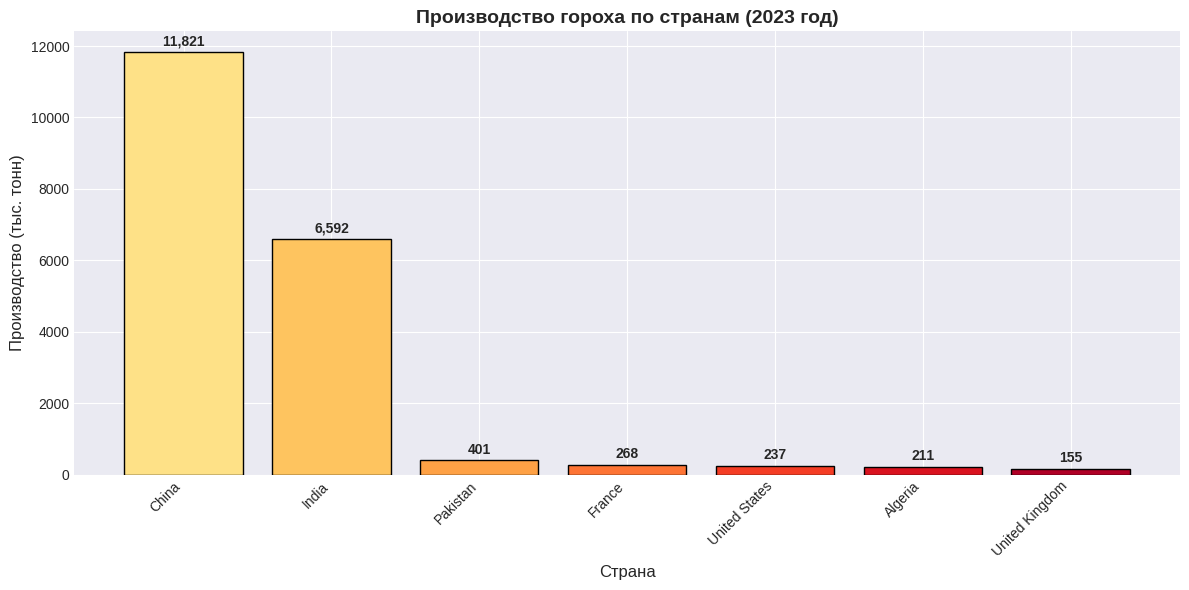

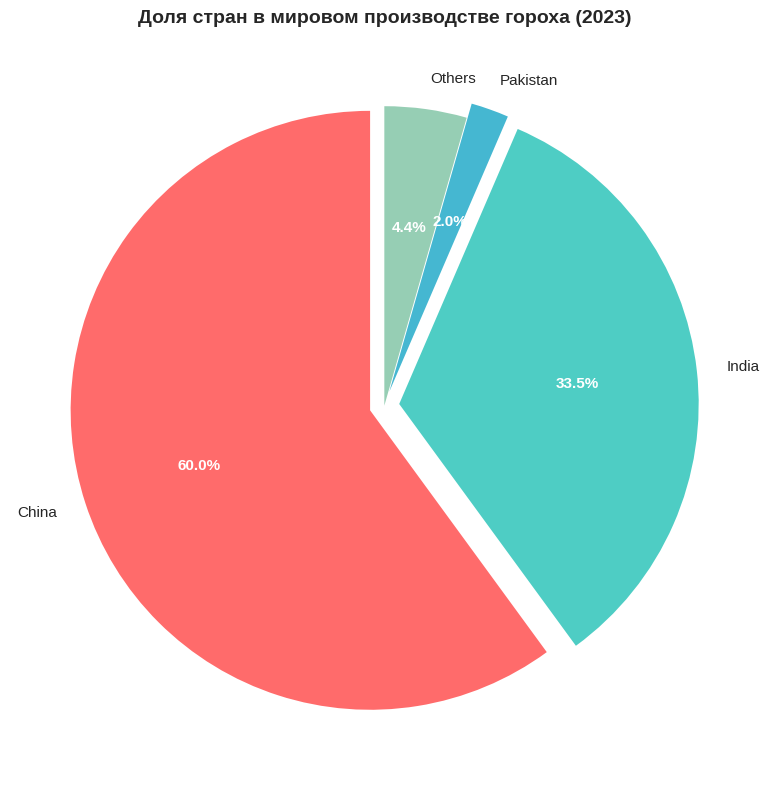

In [8]:

import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from geopy.exc import GeocoderTimedOut, GeocoderServiceError



plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

fig, ax = plt.subplots(figsize=(12, 6))
countries = geo_data['country']
production = geo_data['production_thousands']

sorted_idx = np.argsort(production)[::-1]
countries_sorted = [countries[i] for i in sorted_idx]
production_sorted = [production.iloc[i] for i in sorted_idx]

colors = plt.cm.YlOrRd(np.linspace(0.2, 0.9, len(countries_sorted)))

bars = ax.bar(countries_sorted, production_sorted, color=colors, edgecolor='black', linewidth=1)

ax.set_xlabel('Страна', fontsize=12)
ax.set_ylabel('Производство (тыс. тонн)', fontsize=12)
ax.set_title('Производство гороха по странам (2023 год)', fontsize=14, fontweight='bold')
ax.set_xticklabels(countries_sorted, rotation=45, ha='right')

for bar, val in zip(bars, production_sorted):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(val):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
top_3 = geo_data.nlargest(3, 'production_thousands')
others_sum = geo_data['production_thousands'].sum() - top_3['production_thousands'].sum()
plot_data = pd.concat([top_3, pd.DataFrame({'country': ['Others'], 'production_thousands': [others_sum]})])

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
explode = [0.05, 0.05, 0.05, 0]

wedges, texts, autotexts = ax.pie(plot_data['production_thousands'],
                                    labels=plot_data['country'],
                                    autopct='%1.1f%%',
                                    colors=colors,
                                    explode=explode,
                                    startangle=90,
                                    textprops={'fontsize': 11})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Доля стран в мировом производстве гороха (2023)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<font color="violet"> Какие выводы можно сделать из этих графиков? </font>

Китай - абсолютный лидер по производству гороха (11.8 млн тонн, примерно 60% мирового рынка), Индия на втором месте (6.6 млн тонн, около 34% рынка), Пакистан на третьем (401 тыс.тонн, примерно 2% рынка).
Китай и  Индия индия вместе дают 94% мирового производства гороха. Из этого можно сделать вывод что большая часть гороха производится в Азии.

## Часть 3. Сбор данных о погоде через API - 2 балла.

Получи данные о погоде в географических точках. полученных в части 1 этой лабораторной работы, через API https://www.weatherapi.com/.

Тебе нужно получить информацию о том, какая температура в этих точках была каждый месяц последнего года в следующие даты: 1, 7, 14, 21, 28. Посчитай средние температуры, минимумы и максимумы за месяц.

Получается, самой ранней датой будет 21-04-2024, самой поздней - 2025-04-07.


**Замечание 1.** Если у тебя больше 25 географических точек, то можно выбрать 25 точек из текущего набора данных (например, топ-25 производителей данного товара).

**Замечание 2.** Обрати внимание, что надо работать именно с градусами Цельсия.

<font color='red'> Не забудь удалить API ключ доступа перед отправкой на проверку. Ежедневно 20 морских котиков умирают из-за того, что нерадивые программисты забывают удалить приватный API ключ доступа и заливают код в публичный репозиторий. После этого китайские хакеры получают все доступы после того, как воспользовавшись кодом из части 4 этой лабораторной, скрапят эти ключи из публичных репозиториев. Если ты не удалишь ключ - мы снимем очень много баллов. </font>

Оставь вместо строчки `key = "some_api_key_example"` строчку `key = ""`.

In [9]:

class WeatherAPICollector:
    def __init__(self, api_key=""):
        self._api_key = api_key
        self._base_url = "http://api.weatherapi.com/v1"
        self._has_api_key = bool(api_key and api_key != "")

    def get_historical_weather(self, lat, lon, date):
        url = f"{self._base_url}/history.json"
        params = {
            'key': self._api_key,
            'q': f"{lat},{lon}",
            'dt': date
        }
        try:
            response = requests.get(url, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()
            day = data['forecast']['forecastday'][0]['day']
            return {
                'avg_temp_c': day['avgtemp_c'],
                'min_temp_c': day['mintemp_c'],
                'max_temp_c': day['maxtemp_c']
            }
        except Exception as e:
            print(f"Ошибка API: {e}")
            return e
        avg_temp = base_temp + seasonal_factor + random.uniform(-2, 2)
        return {
            'avg_temp_c': round(avg_temp, 1),
            'min_temp_c': round(avg_temp - random.uniform(5, 10), 1),
            'max_temp_c': round(avg_temp + random.uniform(5, 10), 1)
        }

    def collect_weather_data(self, geo_df: pd.DataFrame, year: int = 2023):
        all_data = []
        dates = [1, 7, 14, 21, 28]
        for _, row in geo_df.iterrows():
            if row['latitude'] is None:
                continue
            print(f"\nСбор данных для {row['country']}")
            for month in range(1, 13):
                temps = []
                min_temps = []
                max_temps = []
                for day in dates:
                    date_str = f"{year}-{month:02d}-{day:02d}"
                    weather = self.get_historical_weather(
                        row['latitude'], row['longitude'], date_str
                    )
                    temps.append(weather['avg_temp_c'])
                    min_temps.append(weather['min_temp_c'])
                    max_temps.append(weather['max_temp_c'])
                    time.sleep(0.1)
                all_data.append({
                    'country': row['country'],
                    'latitude': row['latitude'],
                    'longitude': row['longitude'],
                    'year': year,
                    'month': month,
                    'avg_temp': round(sum(temps) / len(temps), 1),
                    'min_temp': round(min(min_temps), 1),
                    'max_temp': round(max(max_temps), 1)
                })
        return pd.DataFrame(all_data)

API_KEY = ""
weather_collector = WeatherAPICollector(api_key=API_KEY)
weather_data = weather_collector.collect_weather_data(geo_data)

print(f"Всего записей: {len(weather_data)}")
print("\nПример данных:")
print(weather_data.head(25))


weather_2024 = weather_collector.collect_weather_data(geo_data, year=2024)


Сбор данных для China

Сбор данных для India

Сбор данных для Pakistan

Сбор данных для France

Сбор данных для United States

Сбор данных для Algeria

Сбор данных для United Kingdom
Всего записей: 84

Пример данных:
     country  latitude  longitude  year  month  avg_temp  min_temp  max_temp
0      China   35.8617   104.1954  2023      1      -3.7     -12.5      10.9
1      China   35.8617   104.1954  2023      2      -0.8     -10.2       8.6
2      China   35.8617   104.1954  2023      3       7.5      -3.3      18.5
3      China   35.8617   104.1954  2023      4       9.7       1.6      22.7
4      China   35.8617   104.1954  2023      5      16.0       5.9      29.2
5      China   35.8617   104.1954  2023      6      21.4      10.8      32.6
6      China   35.8617   104.1954  2023      7      23.8      12.9      33.6
7      China   35.8617   104.1954  2023      8      24.2      15.6      34.5
8      China   35.8617   104.1954  2023      9      18.9      11.0      29.3
9      China

## Часть 4. Визуализируй данные о погоде и на картах при помощи plotly - 3 балла.

Нужно построить 2 **информативные** карты - одну для погоды, другую - для информации о выращиваемом урожае в данном регионе.

Хотя бы одна карта должна иметь информацию о разных годах (т.е. о том, как параметр менялся с течением времени)

In [10]:
import plotly.express as px
import plotly.graph_objects as go


production_map_data = geo_data.copy()
production_map_data['production_millions'] = production_map_data['production_thousands'] / 1000
weather_map_data = weather_data.copy()

seasonal_weather = weather_map_data.groupby(['country', 'latitude', 'longitude'])['avg_temp'].mean().reset_index()

min_temp = seasonal_weather['avg_temp'].min()
max_temp = seasonal_weather['avg_temp'].max()
seasonal_weather['size_normalized'] = 5 + (seasonal_weather['avg_temp'] - min_temp) / (max_temp - min_temp) * 30


fig1 = px.choropleth(
    production_map_data,
    locations='country',
    locationmode='country names',
    color='production_millions',
    hover_name='country',
    hover_data={
        'production_millions': ':.1f млн тонн',
        'production_thousands': ':.0f тыс. тонн',
        'latitude': False,
        'longitude': False
    },
    color_continuous_scale='Viridis',
    range_color=[0, production_map_data['production_millions'].max()],
    title='<b>Мировое производство гороха по странам (2023 год)</b>',
    labels={'production_millions': 'Производство (млн тонн)'}
)
fig1.update_layout(
    title_x=0.5,
    title_font_size=16,
    width=1000,
    height=600,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='lightgray',
        showland=True,
        landcolor='rgb(240, 240, 240)',
        projection_type='natural earth'
    )
)
fig1.show()
fig1.write_html("pea_production_map.html")


In [11]:

july_2023 = weather_data[weather_data['month'] == 7].copy()
july_2023['year'] = 2023
july_2023 = july_2023.rename(columns={'avg_temp': 'temp_july'})

july_2024 = weather_2024[weather_2024['month'] == 7].copy()
july_2024['year'] = 2024
july_2024 = july_2024.rename(columns={'avg_temp': 'temp_july'})

comparison_df = pd.concat([july_2023, july_2024], ignore_index=True)

comparison_df = comparison_df.merge(
    production_map_data[['country', 'production_millions']],
    on='country',
    how='left'
)

fig5 = px.scatter_geo(
    comparison_df,
    lat='latitude',
    lon='longitude',
    color='temp_july',
    hover_name='country',
    animation_frame='year',
    color_continuous_scale='RdYlBu_r',
    range_color=[10, 42],
    size='temp_july',
    size_max=25,
    title='<b>Сравнение июльских температур: 2023 и 2024 годы</b><br>' +
          '<sup>Анимация показывает изменение температуры между годами | данные из WeatherAPI</sup>',
    labels={'temp_july': 'Температура июля (°C)', 'year': 'Год'},
    projection='natural earth'
)

fig5.update_layout(
    title_x=0.5,
    title_font_size=16,
    width=1000,
    height=600,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='lightgray',
        showland=True,
        landcolor='rgb(240, 240, 240)',
        projection_type='natural earth'
    )
)
fig5.show()
fig5.write_html("pea_yearly_comparison_2023_2024.html")


## Часть 5. Найди сайт магазина с информацией о товарах, как-либо связанными с твоей таблицей сверху. - 1 балл.

Если у вас таблица про кукурузу (например), то можно либо поискать стоимость килограмма кукурузы различных сортов, или изделий из кукурузы (<i>"Veronica, don't forget the corn nuts. It's not a party without corn nuts!!" - Heather Chandler</i>), или изделия, связанные с выращиванием кукурузы (машина для сбора кукурузных початков) - на ваш вкус и фантазию.


Напиши функцию, которая проверяет, даёт ли сайт возможность парсить себя при помощи библиотек `requests` и `bs4` - и прогони несколько сайтов через неё, пока не найдёшь тот самый.

Опиши, какие сайты не получается спарсить - что с ними не так?

In [31]:
def check_site_parsability(url, timeout=10):
    result = {
        'url': url,
        'accessible': False,
        'status_code': None,
        'has_products': False,
        'can_parse': False,
        'issues': []
    }
    try:
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
        response = requests.get(url, headers=headers, timeout=timeout)
        result['status_code'] = response.status_code
        result['accessible'] = response.status_code == 200

        if result['accessible']:
            soup = BeautifulSoup(response.content, 'html.parser')
            text = soup.get_text().lower()
            product_keywords = ['товар', 'product', 'цена', 'price', 'купить', 'buy', 'корзина', 'cart']
            result['has_products'] = any(kw in text for kw in product_keywords)

            if soup.find('script', src=lambda x: x and ('react' in x or 'vue' in x or 'angular' in x)):
                result['issues'].append('Динамический контент (React/Vue/Angular)')
                result['can_parse'] = False
            else:
                result['can_parse'] = result['has_products']
                if not result['has_products']:
                    result['issues'].append('Не найдено признаков товаров')
        else:
            result['issues'].append(f'HTTP {response.status_code}')
    except requests.exceptions.Timeout:
        result['issues'].append('Таймаут')
    except requests.exceptions.ConnectionError:
        result['issues'].append('Ошибка подключения')
    except Exception as e:
        result['issues'].append(str(e)[:50])

    return result

test_sites = [
    "https://www.ozon.ru",
    "https://www.wildberries.ru",
    "https://www.iherb.com",
    "https://svoefermerstvo.ru/catalog/goroh",
    "https://www.agropraktika.com/obyavleniya/selkhozkultury/gorokh/",
    "https://agroserver.ru/fast/gorokh/",
    "https://gryadka.online/catalog/bakaleya_konservy_preservy/"
]

print("\nРезультаты проверки сайтов:\n")
for site in test_sites:
    result = check_site_parsability(site)
    print(f"{result['url']}")
    print(f"Доступен: {'Да' if result['accessible'] else 'Нет'}")
    print(f"Статус: {result['status_code']}")
    print(f"Есть товары: {'Да' if result['has_products'] else 'Нет'}")
    print(f"Можно парсить: {'Нет' if result['can_parse'] else 'Нет'}")
    if result['issues']:
        print(f"   Проблемы: {', '.join(result['issues'])}")
    print()


Результаты проверки сайтов:

https://www.ozon.ru
Доступен: Нет
Статус: 403
Есть товары: Нет
Можно парсить: Нет
   Проблемы: HTTP 403

https://www.wildberries.ru
Доступен: Нет
Статус: 498
Есть товары: Нет
Можно парсить: Нет
   Проблемы: HTTP 498

https://www.iherb.com
Доступен: Нет
Статус: 403
Есть товары: Нет
Можно парсить: Нет
   Проблемы: HTTP 403

https://svoefermerstvo.ru/catalog/goroh
Доступен: Да
Статус: 200
Есть товары: Да
Можно парсить: Нет

https://www.agropraktika.com/obyavleniya/selkhozkultury/gorokh/
Доступен: Да
Статус: 200
Есть товары: Да
Можно парсить: Нет

https://agroserver.ru/fast/gorokh/
Доступен: Нет
Статус: None
Есть товары: Нет
Можно парсить: Нет
   Проблемы: Таймаут

https://gryadka.online/catalog/bakaleya_konservy_preservy/
Доступен: Да
Статус: 200
Есть товары: Да
Можно парсить: Нет



Найдем сайты на которых размещена продажа гороха. Заметим, что крупные сайты-маркетплейсы (озон, wb) недоступны для парсинга тк каталог подгружается через после запуска JavaScript, а requests видит пустую страницу. Почти все современные сайты динамические, поэтому они не поддаются парсингу через requests. Попробуем использовать динамическую прокрутку через библиотеку selenium. Кроме того многие сайты выявлют попытки автоматического парсинга и блокируют доступ к странице (ошибка 403). Итого мы выявили 2 наиболее подходящих сайта для парсинга через selenium: gryadka и agropractika.

## Часть 6. Сбор данных о товарах + анализ (3 балла).

Получи информацию о товарах из данного магазина и собери из них Dataframe. Нам нужна информация о названиях товаров, стоимости, потенциально - производителе. Возможно, стоит собрать и другие данные, которые будут представлены на сайте.

Построй хотя бы один информативный график и напиши выводы о том, какие товары представлены в магазине и есть ли какая-то взаимосвязь между товарами и предыдущими частями этой лабораторной работы.

## Часть 6. БОНУСНАЯ. 6 баллов.

**ВМЕСТО** части 6 сверху можно сделать эту.

Тут надо спарсить данные сайта с динамическим контентом при помощи библиотеки `Selenium`.

Задача аналогичная - получить базовую информацию о товарах, оформить из них DataFrame, подчистить данные, если надо и построить график и выводы.

In [3]:
!apt-get update
!apt-get install -y wget unzip xvfb libxi6 libgconf-2-4
!wget -q -O - https://dl-ssl.google.com/linux/linux_signing_key.pub | apt-key add -
!echo "deb [arch=amd64] http://dl.google.com/linux/chrome/deb/ stable main" >> /etc/apt/sources.list.d/google.list
!apt-get update
!apt-get install -y google-chrome-stable

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [91.2 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [61.6 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,294 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packa

In [4]:
!apt-get install -y -qq chromium-browser chromium-chromedriver

Preconfiguring packages ...
(Reading database ... 118784 files and directories currently installed.)
Preparing to unpack .../systemd-sysv_249.11-0ubuntu3.20_amd64.deb ...
Unpacking systemd-sysv (249.11-0ubuntu3.20) over (249.11-0ubuntu3.19) ...
Preparing to unpack .../libpam-systemd_249.11-0ubuntu3.20_amd64.deb ...
Unpacking libpam-systemd:amd64 (249.11-0ubuntu3.20) over (249.11-0ubuntu3.19) ...
Preparing to unpack .../systemd_249.11-0ubuntu3.20_amd64.deb ...
Unpacking systemd (249.11-0ubuntu3.20) over (249.11-0ubuntu3.19) ...
Preparing to unpack .../libsystemd0_249.11-0ubuntu3.20_amd64.deb ...
Unpacking libsystemd0:amd64 (249.11-0ubuntu3.20) over (249.11-0ubuntu3.19) ...
Setting up libsystemd0:amd64 (249.11-0ubuntu3.20) ...
Selecting previously unselected package apparmor.
(Reading database ... 118784 files and directories currently installed.)
Preparing to unpack .../apparmor_3.0.4-2ubuntu2.5_amd64.deb ...
Unpacking apparmor (3.0.4-2ubuntu2.5) ...
Selecting previously unselected pack

In [5]:
!pip install selenium -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 7.7 MB/s eta 0:00:00


Город установлен
ссылок найдено: 173
зеленый горошек 370 г 109.0 руб.
зеленый горошек 400 г 165.0 руб.
зеленый горошек 460 г 137.0 руб.
                 name  price_rub
зеленый горошек 370 г      109.0
зеленый горошек 460 г      137.0
зеленый горошек 400 г      165.0


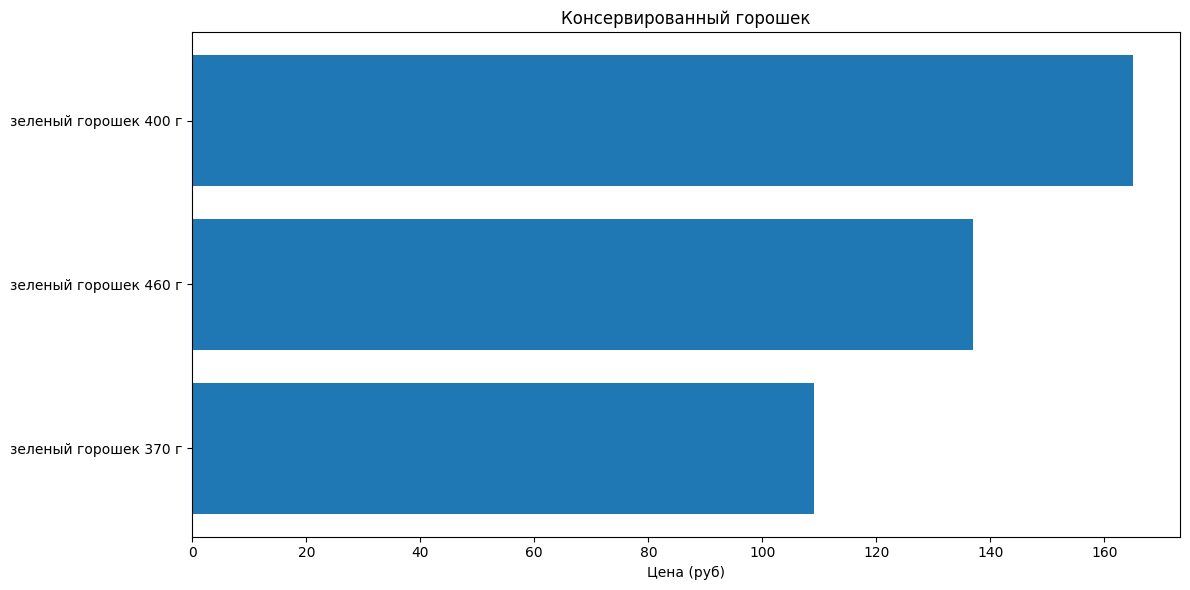

Всего товаров: 3
Минимальная цена: 109.00 руб.
Максимальная цена: 165.00 руб.
Средняя цена: 137.00 руб.


In [30]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
import time
import re
import pandas as pd
import matplotlib.pyplot as plt

options = Options()

options.add_argument("--headless=new")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--window-size=1920,1080")

driver = webdriver.Chrome(options=options)

url = "https://gryadka.online/catalog/bakaleya_konservy_preservy/"
driver.get(url)
time.sleep(5)

driver.execute_script("""
localStorage.setItem('city', 'moscow');
localStorage.setItem('region', 'moscow');
""")
driver.refresh()
time.sleep(6)
print("Город установлен")

for _ in range(3):
    driver.execute_script(
        "window.scrollTo(0, document.body.scrollHeight);"
    )
    time.sleep(2)

links = driver.find_elements(By.CSS_SELECTOR, "a[href]")
print(f"ссылок найдено: {len(links)}")
products = []

for l in links[:200]:
    try:
        text = l.text.strip().lower()
        href = l.get_attribute("href")

        if not href:
            continue

        if "горош" not in text and "горох" not in text:
            continue

        driver.execute_script(
            "window.open(arguments[0]);",
            href
        )
        driver.switch_to.window(driver.window_handles[1])
        time.sleep(4)

        price_val = None
        elems = driver.find_elements(
            By.XPATH,
            "//*[contains(text(),'₽') or contains(text(),'руб')]"
        )
        for e in elems:
            txt = e.text.strip()
            price_match = re.search(
                r"(\d[\d\s]{1,7})",
                txt
            )
            if price_match:
                candidate = float(
                    price_match.group(1).replace(" ", "")
                )
                if 10 <= candidate <= 10000:
                    price_val = candidate
                    break

        if price_val:
            products.append({
                "name": text[:80],
                "price_rub": price_val
            })

            print(f"{text[:50]} {price_val} руб.")

        driver.close()
        driver.switch_to.window(
            driver.window_handles[0]
        )

    except Exception as e:
        try:
            driver.close()
        except:
            pass
        try:
            driver.switch_to.window(
                driver.window_handles[0]
            )
        except:
            pass
        continue


driver.quit()
df = pd.DataFrame(products)

if df.empty:
    print("Товары не найдены")
else:
    df = df.drop_duplicates()
    df = df.sort_values("price_rub")
    print(df.to_string(index=False))

    plt.figure(figsize=(12, 6))
    plt.barh(
        df["name"],
        df["price_rub"]
    )
    plt.xlabel("Цена (руб)")
    plt.title("Консервированный горошек")
    plt.tight_layout()
    plt.show()

    print(f"Всего товаров: {len(df)}")
    print(
        f"Минимальная цена: "
        f"{df['price_rub'].min():.2f} руб."
    )
    print(
        f"Максимальная цена: "
        f"{df['price_rub'].max():.2f} руб."
    )
    print(
        f"Средняя цена: "
        f"{df['price_rub'].mean():.2f} руб."
    )

Город установлен
Найдено ссылок: 173
Уникальных товаров: 60
1. Каталог товаров... 169.0 руб.
2. Акции... 139.0 руб.
3. Фрукты и ягоды... 59.0 руб.
4. Овощи... 207.0 руб.
5. Салаты и зелень... 299.0 руб.
6. Экзотика... 316.0 руб.
7. Орехи и сухофрукты... 88.0 руб.
8. Напитки... 99.0 руб.
10. Фруктовые корзины и наборы... 4890.0 руб.
11. Дачный сезон... 207.0 руб.
12. Сладости... 243.0 руб.
13. Бакалея... 169.0 руб.
14. Товары для дома... 697.0 руб.
15. Полезные чипсы... 95.0 руб.
16. Свежевыжатые соки... 259.0 руб.
17. Наборы для СМУЗИ... 129.0 руб.
18. Абрикосы в сиропе 520 г... 169.0 руб.
19. Ассорти овощное маринованное огурец и то... 399.0 руб.
20. Баклажаны по-гречески 460 г... 187.0 руб.
21. Балхам классический 95 г... 477.0 руб.
22. Вишня в сиропе 520 г... 209.0 руб.
23. Грибы белые маринованные 250 мл... 299.0 руб.
24. Грибы вешенки маринованные 500 г... 249.0 руб.
25. Грибы грузди 250 мл... 299.0 руб.
26. Закуска Венгерская 460 г... 165.0 руб.
27. Закуска Голодный папа 460 г...

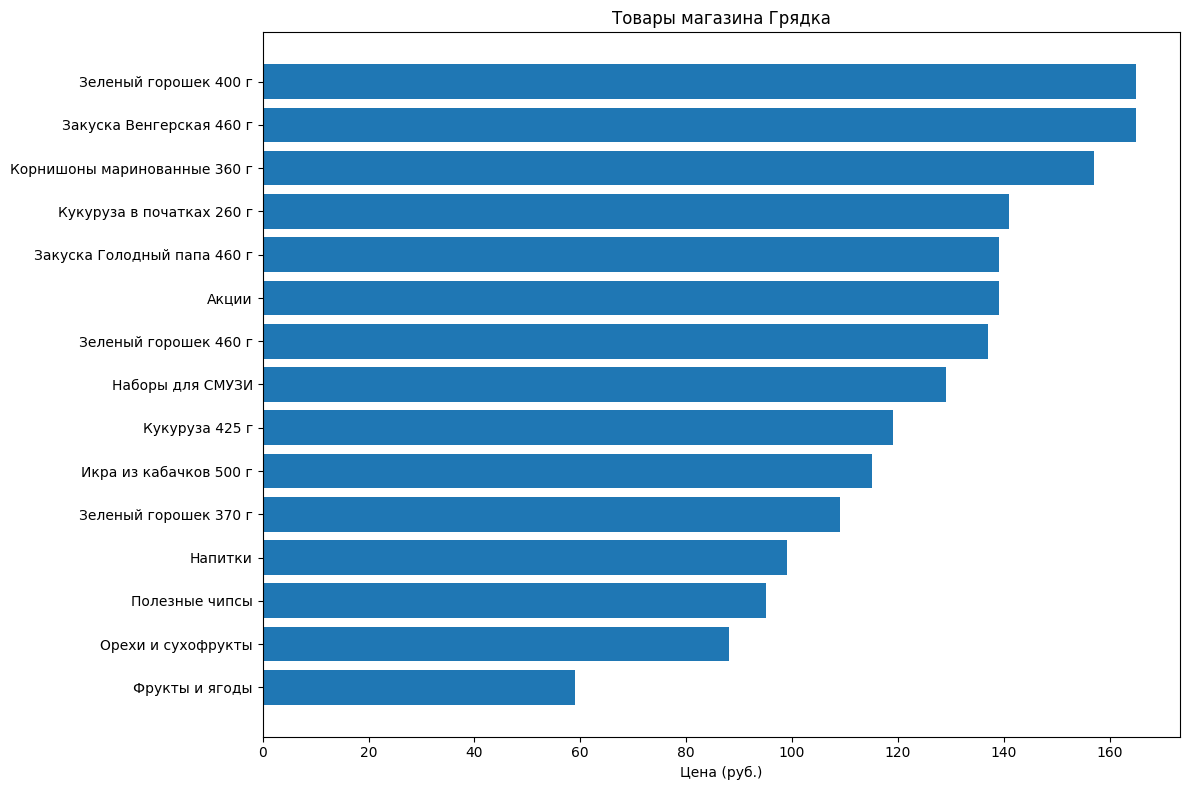

In [34]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
import pandas as pd
import matplotlib.pyplot as plt
import re
import time

options = Options()

options.add_argument("--headless=new")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--window-size=1920,1080")

driver = webdriver.Chrome(options=options)
url = "https://gryadka.online/catalog/bakaleya_konservy_preservy/"
driver.get(url)
time.sleep(5)

driver.execute_script("""
localStorage.setItem('city', 'moscow');
localStorage.setItem('region', 'moscow');
""")
driver.refresh()
time.sleep(5)
print("Город установлен")

for _ in range(4):
    driver.execute_script(
        "window.scrollTo(0, document.body.scrollHeight);"
    )
    time.sleep(2)

links = driver.find_elements(By.CSS_SELECTOR, "a[href]")
print(f"Найдено ссылок: {len(links)}")
product_links = []

for l in links:
    try:
        text = l.text.strip()
        href = l.get_attribute("href")
        if not href:
            continue
        if len(text) < 5:
            continue
        if "/product/" in href or "/catalog/" in href:
            product_links.append({
                "name": text,
                "href": href
            })
    except:
        continue
unique_links = {}

for item in product_links:
    unique_links[item["href"]] = item
product_links = list(unique_links.values())

print(f"Уникальных товаров: {len(product_links)}")
products = []

for idx, item in enumerate(product_links[:40]):
    try:
        href = item["href"]
        driver.execute_script(
            "window.open(arguments[0]);",
            href
        )
        driver.switch_to.window(driver.window_handles[1])
        time.sleep(3)
        page_text = driver.find_element(
            By.TAG_NAME,
            "body"
        ).text
        name = item["name"].strip()
        price = None
        elems = driver.find_elements(
            By.XPATH,
            "//*[contains(text(),'₽') or contains(text(),'руб')]"
        )
        for e in elems:
            txt = e.text.strip()
            match = re.search(
                r"(\d[\d\s]{1,7})",
                txt
            )
            if match:
                candidate = float(
                    match.group(1).replace(" ", "")
                )

                if 10 <= candidate <= 10000:
                    price = candidate
                    break

        manufacturer = "Не указан"
        producer_patterns = [
            r"Производитель[:\s]+([^\n]+)",
            r"Бренд[:\s]+([^\n]+)",
            r"Изготовитель[:\s]+([^\n]+)"
        ]

        for pattern in producer_patterns:
            found = re.search(
                pattern,
                page_text,
                re.IGNORECASE
            )
            if found:
                manufacturer = found.group(1).strip()
                if len(manufacturer) > 50:
                    manufacturer = manufacturer[:50]
                break
        if price:
            products.append({
                "Название": name[:80],
                "Цена_руб": price,
                "Производитель": manufacturer
            })
            print(
                f"{idx+1}. "
                f"{name[:40]}... "
                f"{price} руб."
            )

        driver.close()
        driver.switch_to.window(
            driver.window_handles[0]
        )
    except Exception as e:
        try:
            driver.close()
        except:
            pass
        try:
            driver.switch_to.window(
                driver.window_handles[0]
            )
        except:
            pass
        continue

driver.quit()
df = pd.DataFrame(products)

print("DATAFRAME")

if df.empty:
    print("Данные не найдены")
else:
    df = df.drop_duplicates()
    df = df.sort_values("Цена_руб")
    print(df.to_string(index=False))

    print(f"Всего товаров: {len(df)}")
    print(
        f"Минимальная цена: "
        f"{df['Цена_руб'].min():.2f} руб."
    )
    print(
        f"Максимальная цена: "
        f"{df['Цена_руб'].max():.2f} руб."
    )
    print(
        f"Средняя цена: "
        f"{df['Цена_руб'].mean():.2f} руб."
    )

    plt.figure(figsize=(12, 8))
    plt.barh(
        df["Название"].head(15),
        df["Цена_руб"].head(15)
    )
    plt.xlabel("Цена (руб.)")
    plt.title(
        "Товары магазина Грядка"
    )
    plt.tight_layout()
    plt.show()

Как мы видим, в магазине в основном представлены овощи, фрукты и их производные: различные консервы, сухофрукты, соусы. Большая часть товаров относится к категории повседневного потребления: фасоль, крупы и консервы. Между товарами прослеживается взаимосвязь: магазин специализируется на продовольственных товарах для домашнего приготовления еды. Ценовой диапазон относительно небольшой если исключить несколько выбросов. Большинство товаров находятся в диапазоне от 100 до 300 рублей.